# Homework 1 — Adversarial validation

A classifier tries to tell two sets of rows apart, using only the model's input features.

- **AUC ≈ 0.5:** the sets look the same to a model.
- **AUC well above 0.5:** they differ; feature importances show where.

Questions:

1. Does the test set (2017–2018) look like the training data (2016)?
2. Does a single split (train Jan–Sep, validate Oct–Dec 2016, the split the project first used) look like the
   test set?

Classifier: LightGBM (200 trees, 63 leaves), 500K rows per set, AUC on a held-out 20%. Features: the models' inputs
(`meter`, `primary_use`, `square_feet`, `year_built`, weather, hour, day of week); no target. Training rows exclude
anomalies, as the models do; validation and test rows are kept whole.

In [1]:
import sys

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

sys.path.insert(0, "..")  # the ashrae package lives in the homework folder
from ashrae.data import read_processed

WEATHER = ["air_temperature", "dew_temperature", "sea_level_pressure", "wind_speed", "wind_direction"]
FEATURES = ["meter", "primary_use", "square_feet", "year_built", *WEATHER, "hour", "dayofweek"]
COLUMNS = ["meter", "primary_use", "square_feet", "year_built", *WEATHER, "timestamp", "local_timestamp"]


def load(name, extra=()):
    df = read_processed(name, columns=COLUMNS + list(extra))
    return df.assign(
        meter=df.meter.astype("category"),
        hour=df.local_timestamp.dt.hour,
        dayofweek=df.local_timestamp.dt.dayofweek,
    )


train = load("train_merged.parquet", ["anomaly"])
test = load("test_merged.parquet")
train_clean = train[~train.anomaly]  # what the models are trained on
print(f"train rows: {len(train):,} ({len(train_clean):,} without anomalies)  |  test rows: {len(test):,}")

train rows: 20,216,100 (19,617,014 without anomalies)  |  test rows: 41,697,600


In [2]:
def adversarial(a, b, features=FEATURES, n=500_000):
    """AUC of LightGBM telling rows of `a` from rows of `b`, and each feature's share of the gain."""
    rows = pd.concat([a.sample(n, random_state=0), b.sample(n, random_state=0)], ignore_index=True)
    y = np.r_[np.zeros(n), np.ones(n)]
    X_tr, X_te, y_tr, y_te = train_test_split(rows[features], y, test_size=0.2, random_state=0, stratify=y)
    model = lgb.LGBMClassifier(n_estimators=200, num_leaves=63, random_state=0, verbose=-1).fit(X_tr, y_tr)
    auc = roc_auc_score(y_te, model.predict_proba(X_te)[:, 1])
    gain = pd.Series(model.booster_.feature_importance("gain"), index=features)
    return auc, (gain / gain.sum()).sort_values()

## 1. Training data (2016) vs test (2017–2018)

,AUC
all features,0.751
without weather,0.520
weather only,0.711
air_temperature alone,0.526
dew_temperature alone,0.541
sea_level_pressure alone,0.535
wind_speed alone,0.511
wind_direction alone,0.515


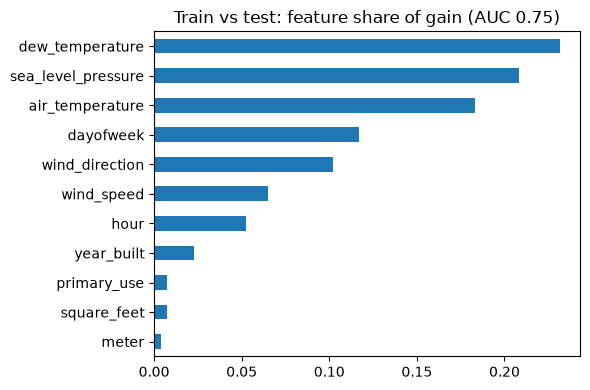

In [3]:
auc_all, gain_all = adversarial(train_clean, test)

aucs = {
    "all features": auc_all,
    "without weather": adversarial(train_clean, test, [f for f in FEATURES if f not in WEATHER])[0],
    "weather only": adversarial(train_clean, test, WEATHER)[0],
    **{f"{w} alone": adversarial(train_clean, test, [w])[0] for w in WEATHER},
}
display(pd.Series(aucs, name="AUC").round(3).to_frame())

gain_all.plot.barh(figsize=(6, 4), title=f"Train vs test: feature share of gain (AUC {auc_all:.2f})")
plt.tight_layout()

- **AUC 0.75, but 0.52 without weather.** Buildings, meters and calendar barely differ. The 0.02 above 0.5 comes from
  dropping anomalies: 15 of 2,380 series lose over half their training rows.
- **Each weather feature alone: 0.51–0.54.** Their distributions barely change between years.
- **Together: 0.71**, because exact combinations (this temperature, pressure and wind) fingerprint one hour of one
  year. A model can't learn from or be hurt by that.
- **Conclusion:** no feature needs dropping. Limit: this checks inputs only; it can't see buildings changing between
  years (e.g. retrofits).

## 2. Our split: Jan–Sep vs Oct–Dec 2016

AUC, all features: 0.924  |  without weather: 0.521


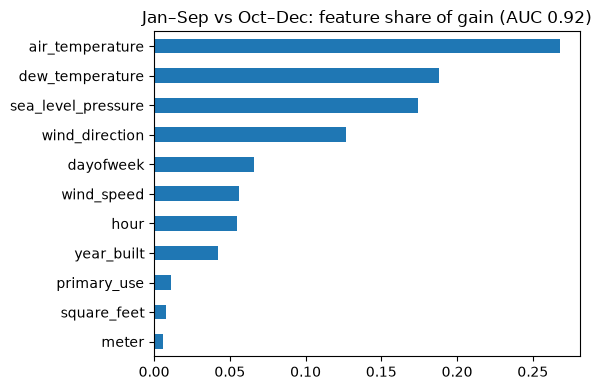

In [4]:
train_months = train_clean[train_clean.timestamp < "2016-10-01"]
val_months = train[train.timestamp >= "2016-10-01"]
auc_split, gain_split = adversarial(train_months, val_months)
auc_split_no_weather = adversarial(train_months, val_months, [f for f in FEATURES if f not in WEATHER])[0]
print(f"AUC, all features: {auc_split:.3f}  |  without weather: {auc_split_no_weather:.3f}")

gain_split.plot.barh(figsize=(6, 4), title=f"Jan–Sep vs Oct–Dec: feature share of gain (AUC {auc_split:.2f})")
plt.tight_layout()

- **AUC 0.92, all from weather** (0.52 without). Temperature carries most of the gain: a real seasonal shift.
- **So Oct–Dec tests one season.** The test set spans whole years; an Oct–Dec score favours what works in autumn and
  says nothing about summer cooling.

## How to use this to tune the MLP

1. **Keep all current features.** Nothing shifts beyond weather fingerprints.
2. **Validate on every season** (every notebook does, from [EDA §9](../eda/EDA.ipynb#broken) to
   [mlp.ipynb](../models/mlp.ipynb)): 4 folds of 3 consecutive months, train on the other nine, compare by mean RMSLE.
   Training on later months is fine: the test set is a later year with known weather.
3. **Tune:**
   - epochs → [epochs_test.ipynb](../models/epochs_test.ipynb);
   - optimizer → [optimizers_test.ipynb](../models/optimizers_test.ipynb);
   - regularization and embedding size → [regularization_test.ipynb](../models/regularization_test.ipynb): no gain.
     The train/validation gap that motivated it is mostly anomaly rows in validation, not overfitting
     ([season_validation.ipynb](season_validation.ipynb)).
4. **Retrain on all of 2016** with the chosen settings, then predict the test set →
   [mlp.ipynb](../models/mlp.ipynb#test-predictions).
5. **Don't reweight rows by adversarial probability:** the difference is a fingerprint, not a real shift.